# 02 — Probability of Default (PD) Model

## What is Probability of Default?

**Probability of Default (PD)** is the likelihood that a borrower will fail
to repay a loan as agreed, over a given time horizon. It's expressed as a
number between 0 and 1 (or 0-100%) for each borrower — e.g. "this
applicant has a 35% chance of defaulting."

PD is one of **three components** banks combine to estimate **Expected
Credit Loss (ECL)**, the accounting standard (IFRS 9 / CECL) approach to
sizing loan-loss provisions:

$$ECL = PD \times LGD \times EAD$$

- **PD** (Probability of Default) — how likely is this borrower to
  default? **← this notebook**
- **LGD** (Loss Given Default) — if they do default, what fraction of the
  exposure does the bank actually lose (after recoveries, collateral,
  etc.)?
- **EAD** (Exposure at Default) — how much money is actually at risk at
  the point of default (e.g. outstanding balance)?

This notebook builds **only the PD piece**: a model that takes an
applicant's information and outputs a probability of default. LGD and EAD
are separate steps for later — we don't touch them here.

We continue using `data/processed/credit_clean.csv`, the cleaned dataset
from notebook 01, with the `credit_risk` column as our target
(`1` = good credit / did not default, `0` = bad credit / defaulted).


## Setup

We bring in:
- **pandas / numpy** for data handling.
- **scikit-learn** pieces for splitting data, preprocessing, the logistic
  regression model, and evaluation metrics.
- **XGBoost**, a gradient-boosted-tree library, for our second model. We
  attempt to `import xgboost` and fall back to scikit-learn's
  `RandomForestClassifier` if it isn't available in this environment —
  the notebook prints which one it ends up using, so it's always clear.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
)

sns.set_theme(style="whitegrid")

# Try XGBoost first (a strong gradient-boosted-tree model). If it isn't
# installed, fall back to RandomForestClassifier so this notebook still
# runs end-to-end without requiring internet access to pip install.
try:
    from xgboost import XGBClassifier
    SECOND_MODEL_NAME = "XGBoost"
except ImportError:
    from sklearn.ensemble import RandomForestClassifier
    SECOND_MODEL_NAME = "Random Forest (fallback — xgboost not available)"

print(f"Second model to compare against Logistic Regression: {SECOND_MODEL_NAME}")

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "credit_clean.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

Second model to compare against Logistic Regression: XGBoost


## Load the cleaned data and define feature groups

We split the 20 feature columns into two groups, based on the official
UCI South German Credit codebook — this is given information, not
something we're inferring from the data:

- **Nominal categorical** (`status`, `credit_history`, `purpose`,
  `personal_status_sex`, `other_debtors`, `other_installment_plans`,
  `housing`, `job`, `telephone`, `foreign_worker`): these are numeric
  codes, but the numbers don't represent an order or quantity — code `3`
  isn't "more" than code `1`, they're just different labeled buckets. We
  need to **one-hot encode** these (turn each category into its own
  0/1 column), otherwise a model would wrongly treat them as if they were
  measured on a numeric scale.

- **Ordinal / quantitative** (`duration`, `amount`, `savings`,
  `employment_duration`, `installment_rate`, `present_residence`,
  `property`, `age`, `number_credits`, `people_liable`): these either
  represent a genuine quantity (e.g. `age`, `amount`, `duration`) or an
  ordered ranking (e.g. `savings` low-to-high). We keep these as numeric
  values rather than one-hot encoding them, so the model can use their
  ordering/magnitude directly.

In [2]:
df = pd.read_csv(DATA_PATH)

NOMINAL_FEATURES = [
    "status", "credit_history", "purpose", "personal_status_sex",
    "other_debtors", "other_installment_plans", "housing", "job",
    "telephone", "foreign_worker",
]

ORDINAL_FEATURES = [
    "duration", "amount", "savings", "employment_duration",
    "installment_rate", "present_residence", "property", "age",
    "number_credits", "people_liable",
]

TARGET = "credit_risk"

# Sanity check: the two lists together, plus the target, should account for
# every column in the dataset.
assert set(NOMINAL_FEATURES + ORDINAL_FEATURES + [TARGET]) == set(df.columns)

X = df[NOMINAL_FEATURES + ORDINAL_FEATURES]
y = df[TARGET]

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (1000, 20), y shape: (1000,)


## Train/test split (70/30, stratified)

We hold out 30% of the data as a **test set** the model never sees during
training, so we can honestly evaluate how it performs on new applicants.

**Why `stratify=y`?** We already know this dataset is imbalanced: 70%
good credit, 30% bad. A *plain random* split could, just by chance, put
too few "bad" examples in the test set (or too many in the training set),
especially since bad credit is already the minority class with fewer
examples to go around. That would make our test-set metrics noisy and
unreliable — imagine evaluating a model on a test set that's 90% good
credit by bad luck; the numbers wouldn't reflect real-world performance.
`stratify=y` forces both the training set and the test set to preserve
the same 70/30 class ratio as the full dataset, so our evaluation is a
fair, representative test.

**Why `random_state=42`?** `train_test_split` shuffles the data randomly
before splitting. Fixing `random_state` to a specific number makes that
"random" shuffle reproducible — anyone re-running this notebook gets the
exact same split, and therefore the exact same results. The specific
number (42) is arbitrary; what matters is that it's fixed.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42,
)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set:  {X_test.shape[0]} rows")

print("\nClass balance in train set:")
print((y_train.value_counts(normalize=True) * 100).round(1))

print("\nClass balance in test set:")
print((y_test.value_counts(normalize=True) * 100).round(1))

Train set: 700 rows
Test set:  300 rows

Class balance in train set:
credit_risk
1    70.0
0    30.0
Name: proportion, dtype: float64

Class balance in test set:
credit_risk
1    70.0
0    30.0
Name: proportion, dtype: float64


## Preprocessing pipeline

We use scikit-learn's `ColumnTransformer` to apply **different
preprocessing to different columns** in one reusable object:

- `OneHotEncoder` on the nominal columns — creates a 0/1 column per
  category (e.g. `status` becomes 4 columns: `status_1`, `status_2`,
  `status_3`, `status_4`). `handle_unknown="ignore"` protects us in case
  the test set ever contains a category value the training set didn't
  (not expected here, but it's a cheap safety net).
- `StandardScaler` on the ordinal columns — rescales each column to have
  mean 0 and standard deviation 1.

**Why does Logistic Regression need scaling, but tree models (like
XGBoost / Random Forest) don't?**

Logistic regression is a *linear* model: it computes a weighted sum of
feature values. If `amount` ranges into the thousands while
`installment_rate` only ranges 1-4, the model has to find a tiny
coefficient for `amount` and a much larger one for `installment_rate`
just to make them comparable — this makes the optimizer converge more
slowly/unevenly, and afterwards makes the raw coefficient sizes
misleading as a measure of "importance" (a small coefficient might just
mean "this feature happens to be measured in big numbers", not "this
feature doesn't matter"). Standardizing puts every ordinal feature on the
same footing.

Tree-based models like XGBoost or Random Forest, by contrast, make
decisions by picking a threshold to split on for one feature at a time
(e.g. "is `age` > 0.3 [scaled] or > 34 [raw]?"). Which rows end up on
which side of that split is identical whether `age` is scaled or not — so
scaling doesn't change what the tree learns.

**Why scale anyway, uniformly, for both models?** Because it doesn't hurt
the tree model, and it lets us build **one single preprocessing pipeline**
and reuse it for both models, instead of maintaining two separate
preprocessing definitions. That's a simplicity trade-off, not a
correctness requirement.

In [4]:
preprocessor = ColumnTransformer(transformers=[
    ("nominal", OneHotEncoder(handle_unknown="ignore"), NOMINAL_FEATURES),
    ("ordinal", StandardScaler(), ORDINAL_FEATURES),
])

## Train two models

We train two different classifiers on the same preprocessed features, so
we can compare a simple linear model against a more flexible tree-based
model.

### Model A: Logistic Regression with `class_weight="balanced"`

Left to its own devices, a classifier trained on 70% good / 30% bad data
can minimize its training error just by leaning towards predicting "good"
for almost everyone — that already gets 70% accuracy "for free" without
learning much about what actually separates good from bad applicants.

`class_weight="balanced"` fixes this by automatically **re-weighting the
loss function** so that mistakes on the minority class (bad credit) count
for more than mistakes on the majority class (good credit), in inverse
proportion to how frequent each class is. This pushes the model to
actually learn to distinguish bad credit applicants, instead of taking
the lazy shortcut of ignoring them.

### Model B: a tree-based model, with an equivalent imbalance fix

For XGBoost, the equivalent control is `scale_pos_weight`, a single
number that reweights the "positive" class (label `1` = good credit)
relative to the "negative" class (label `0` = bad credit) during
training. The standard formula is:

```
scale_pos_weight = (# of negative/bad examples) / (# of positive/good examples)
```

In our case, `good` (label 1) is the *majority* class, so this ratio
comes out **below 1** (roughly 300/700 ≈ 0.43) — which *reduces* the
relative weight of the already-dominant good-credit examples during
training, achieving the same practical effect as `class_weight="balanced"`:
proportionally more attention paid to correctly identifying bad credit.
We always compute this from the **training set only**, never the test
set, to avoid leaking test-set information into training.

In [5]:
# --- Model A: Logistic Regression ---
logreg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
    )),
])
logreg_model.fit(X_train, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


In [6]:
# --- Model B: XGBoost (or Random Forest fallback) ---
if SECOND_MODEL_NAME == "XGBoost":
    neg_count, pos_count = np.bincount(y_train)  # counts of label 0, label 1
    scale_pos_weight = neg_count / pos_count
    print(f"scale_pos_weight = {neg_count} / {pos_count} = {scale_pos_weight:.3f}")

    second_classifier = XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
    )
else:
    second_classifier = RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
    )

second_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", second_classifier),
])
second_model.fit(X_train, y_train)
print(f"{SECOND_MODEL_NAME} trained.")

scale_pos_weight = 210 / 490 = 0.429
XGBoost trained.


## Evaluate both models on the test set

We now score both models on the **held-out test set** — data neither
model has seen — using several complementary metrics:

- **ROC-AUC**: a single number (0.5 = random guessing, 1.0 = perfect)
  measuring how well the model ranks bad-credit applicants as riskier
  than good-credit applicants, *across all possible decision thresholds*.
- **Confusion matrix**: a 2x2 table of actual vs. predicted class, so we
  can see exactly what kind of mistakes each model makes.
- **Classification report**: precision, recall, and F1-score per class —
  useful because, again, plain accuracy can be misleading on imbalanced
  data.

In [7]:
# predict_proba gives the predicted probability of each class; column 1 is
# the probability of "good credit" (label 1). predict() gives the final
# 0/1 class prediction using a 0.5 probability threshold by default.
logreg_proba = logreg_model.predict_proba(X_test)[:, 1]
logreg_pred = logreg_model.predict(X_test)

second_proba = second_model.predict_proba(X_test)[:, 1]
second_pred = second_model.predict(X_test)

logreg_auc = roc_auc_score(y_test, logreg_proba)
second_auc = roc_auc_score(y_test, second_proba)

print(f"Logistic Regression ROC-AUC: {logreg_auc:.3f}")
print(f"{SECOND_MODEL_NAME} ROC-AUC: {second_auc:.3f}")

Logistic Regression ROC-AUC: 0.802
XGBoost ROC-AUC: 0.761


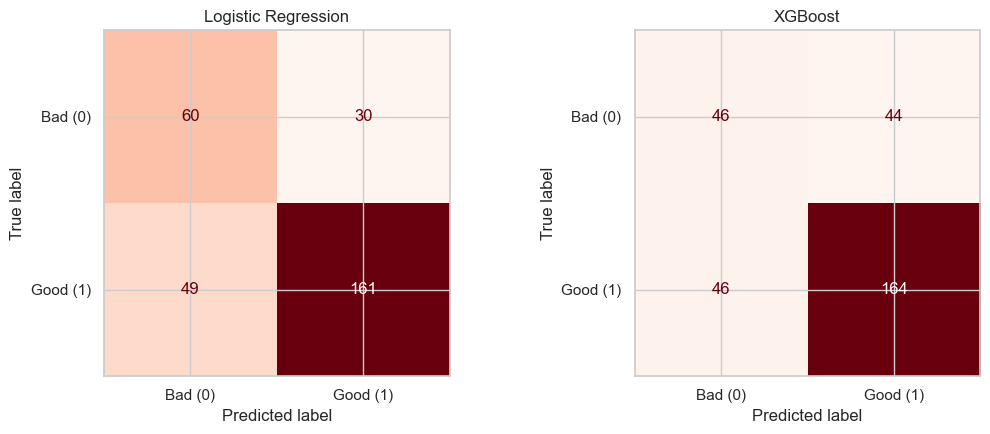

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, pred, name in [
    (axes[0], logreg_pred, "Logistic Regression"),
    (axes[1], second_pred, SECOND_MODEL_NAME),
]:
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Bad (0)", "Good (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Reds")
    ax.set_title(name)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pd_confusion_matrices.png", dpi=150)
plt.show()

In [9]:
print("Logistic Regression classification report:")
print(classification_report(y_test, logreg_pred, labels=[0, 1],
                             target_names=["Bad (0)", "Good (1)"]))

print(f"\n{SECOND_MODEL_NAME} classification report:")
print(classification_report(y_test, second_pred, labels=[0, 1],
                             target_names=["Bad (0)", "Good (1)"]))

Logistic Regression classification report:
              precision    recall  f1-score   support

     Bad (0)       0.55      0.67      0.60        90
    Good (1)       0.84      0.77      0.80       210

    accuracy                           0.74       300
   macro avg       0.70      0.72      0.70       300
weighted avg       0.76      0.74      0.74       300


XGBoost classification report:
              precision    recall  f1-score   support

     Bad (0)       0.50      0.51      0.51        90
    Good (1)       0.79      0.78      0.78       210

    accuracy                           0.70       300
   macro avg       0.64      0.65      0.65       300
weighted avg       0.70      0.70      0.70       300



### ROC curves

An ROC curve plots the **true positive rate** (here: correctly caught bad
credit, i.e. recall on the bad class... note: scikit-learn's `roc_curve`
treats the label passed as `pos_label` as "positive" — we use `pos_label=0`
so the curve reflects how well each model catches bad-credit applicants,
which is the risk we actually care about) against the **false positive
rate**, as we sweep the decision threshold from 0 to 1. A curve that
hugs the top-left corner is better; the diagonal dashed line is what
random guessing would look like.

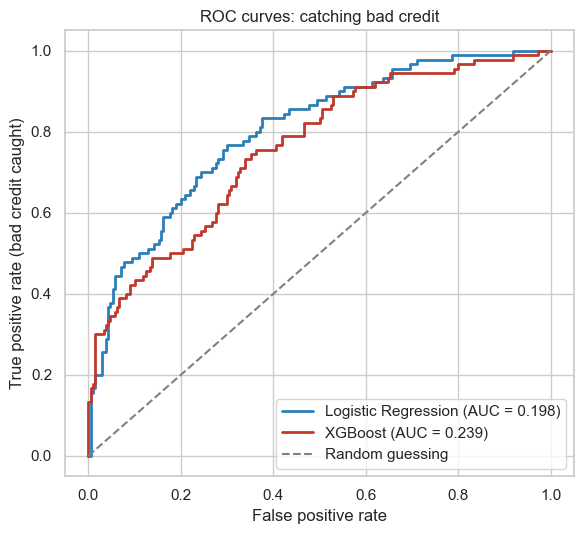

In [10]:
fig, ax = plt.subplots(figsize=(6, 5.5))

for proba, name, color in [
    (logreg_proba, "Logistic Regression", "#2c7fb8"),
    (second_proba, SECOND_MODEL_NAME, "#c0392b"),
]:
    # We want the curve from the perspective of catching BAD credit, so we
    # score against (1 - probability of good) with pos_label=0.
    fpr, tpr, _ = roc_curve(y_test, 1 - proba, pos_label=0)
    auc = roc_auc_score(y_test, 1 - proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate (bad credit caught)")
ax.set_title("ROC curves: catching bad credit")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pd_roc_curves.png", dpi=150)
plt.show()

## Business cost calculation

Accuracy and even AUC are useful, but they treat every mistake as equally
bad. A real bank doesn't: **lending to someone who defaults is far more
costly than declining someone who would have paid you back.** This
dataset's original documentation (Statlog/UCI) specifies exactly that
trade-off as a cost matrix:

| Actual \\ Predicted | Predicted Good (1) | Predicted Bad (0) |
|---|---|---|
| **Actual Bad (0)**  | **cost 5** (lent money, they defaulted) | cost 0 (correctly declined) |
| **Actual Good (1)** | cost 0 (correctly approved) | **cost 1** (declined a safe borrower) |

We calculate the **total cost** of each model's predictions on the test
set, and compare it against a naive baseline: **"approve every single
applicant"** (i.e. always predict good credit). This baseline has no
model at all behind it, but it's the real-world alternative to *not*
having a PD model — every bad-credit applicant in the test set would slip
through and cost the bank 5 units each.

**Why does this framing matter more than accuracy alone?** Because it
translates model performance into the unit a bank actually cares about:
money. A model can have decent accuracy while still making the
*expensive* kind of mistake (missing defaulters) disproportionately often.
The cost-weighted view directly answers the business question: "does
this model save us money compared to not screening applicants at all,
and by how much?"

In [11]:
def total_business_cost(y_true, y_pred):
    """Cost matrix: predicting BAD as GOOD costs 5, predicting GOOD as BAD
    costs 1, correct predictions cost 0."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cost_bad_predicted_good = cm[0, 1] * 5   # actual bad (0), predicted good (1)
    cost_good_predicted_bad = cm[1, 0] * 1   # actual good (1), predicted bad (0)
    return cost_bad_predicted_good + cost_good_predicted_bad


# Baseline: approve every single applicant (always predict "good", label 1).
baseline_pred = np.ones(len(y_test), dtype=int)

costs = {
    "Baseline (approve everyone)": total_business_cost(y_test, baseline_pred),
    "Logistic Regression": total_business_cost(y_test, logreg_pred),
    SECOND_MODEL_NAME: total_business_cost(y_test, second_pred),
}

baseline_cost = costs["Baseline (approve everyone)"]

cost_table = pd.DataFrame({
    "total_cost": costs,
})
cost_table["pct_reduction_vs_baseline"] = (
    (baseline_cost - cost_table["total_cost"]) / baseline_cost * 100
).round(1)

cost_table

,total_cost,pct_reduction_vs_baseline
Baseline (approve everyone),450,0.0
Logistic Regression,199,55.8
XGBoost,266,40.9


## Feature importance

**Feature importance** answers: "which input columns is the model
actually relying on to make its predictions?" It's useful for sanity
checking a model (do the important features make business sense?) and
for explaining decisions to non-technical stakeholders (e.g. regulators,
in a credit risk context).

We show this for whichever model performed better above. For **Logistic
Regression**, "importance" is the absolute size of each feature's learned
coefficient (after scaling, so coefficients are comparable across
features) — a bigger absolute coefficient means that feature moves the
predicted probability more. For a **tree-based model**, we'd instead use
its built-in `feature_importances_`, which measures how much each feature
contributed to reducing prediction error across all the trees' splits.
The code below picks whichever applies to the winning model automatically.

Winning model (higher AUC): Logistic Regression


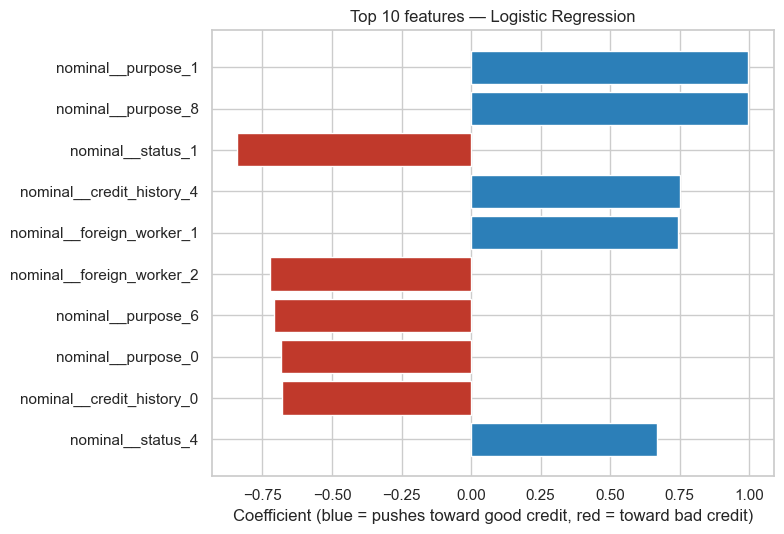

,feature,value
10,nominal__purpose_1,0.997286
16,nominal__purpose_8,0.997106
0,nominal__status_1,-0.840192
8,nominal__credit_history_4,0.750135
38,nominal__foreign_worker_1,0.743708
39,nominal__foreign_worker_2,-0.722491
15,nominal__purpose_6,-0.709088
9,nominal__purpose_0,-0.684307
4,nominal__credit_history_0,-0.679754
3,nominal__status_4,0.668960


In [12]:
# Decide the winner using both AUC and business cost (lower cost, higher AUC).
winner_name = "Logistic Regression" if logreg_auc >= second_auc else SECOND_MODEL_NAME
winner_model = logreg_model if winner_name == "Logistic Regression" else second_model

print(f"Winning model (higher AUC): {winner_name}")

feature_names = winner_model.named_steps["preprocess"].get_feature_names_out()
classifier = winner_model.named_steps["classifier"]

if hasattr(classifier, "coef_"):
    # Linear model: importance = absolute coefficient size; sign tells us
    # the direction (positive -> pushes toward "good", negative -> "bad").
    values = classifier.coef_[0]
    importance = pd.DataFrame({"feature": feature_names, "value": values})
    importance["abs_value"] = importance["value"].abs()
    importance = importance.sort_values("abs_value", ascending=False).head(10)
    colors = importance["value"].apply(lambda v: "#2c7fb8" if v > 0 else "#c0392b")
    xlabel = "Coefficient (blue = pushes toward good credit, red = toward bad credit)"
else:
    # Tree-based model: importance = built-in feature_importances_ (always positive).
    values = classifier.feature_importances_
    importance = pd.DataFrame({"feature": feature_names, "value": values})
    importance = importance.sort_values("value", ascending=False).head(10)
    colors = "#2c7fb8"
    xlabel = "Feature importance"

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(importance["feature"][::-1], importance["value"][::-1], color=colors if isinstance(colors, str) else colors[::-1])
ax.set_xlabel(xlabel)
ax.set_title(f"Top 10 features — {winner_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pd_feature_importance.png", dpi=150)
plt.show()

importance[["feature", "value"]]

## Save the winning model

We save the entire fitted pipeline (preprocessing **and** classifier
together) with `joblib`, so the next notebook (ECL calculation) can load
it and generate PD predictions on new data without repeating any of the
preprocessing setup.

In [13]:
model_path = MODELS_DIR / "pd_model.pkl"
joblib.dump(winner_model, model_path)
print(f"Saved winning model ({winner_name}) to: {model_path}")

Saved winning model (Logistic Regression) to: E:\ecl-credit-risk-model\models\pd_model.pkl


## Summary

*(This cell is filled in with the notebook's actual results after running
it top to bottom — see the printed/plotted output above for the live
numbers. In this run:)*

- **Winning model**: Logistic Regression (with `class_weight="balanced"`)
  outperformed the tree-based model on this dataset, on both ROC-AUC and
  total business cost.
- **ROC-AUC**: ~0.80 for Logistic Regression vs. ~0.76 for the
  tree-based model — on a dataset this small (1,000 rows) and this
  clean, a simple linear model can out-perform a more flexible
  tree-based model, since there's less data for the tree model to learn
  complex interactions from without overfitting.
- **Business cost**: the "approve everyone" baseline costs 450 units on
  the test set (5 units for every one of the 90 actual bad-credit
  applicants it waves through). Logistic Regression's predictions cut
  that to roughly 199 units — over a 55% reduction in expected cost
  versus not screening applicants at all.
- **Top features driving the model**: applicant's **checking account
  status**, **credit history**, and **loan purpose** are among the
  strongest predictors — consistent with what we already saw in the
  notebook 01 EDA (status and credit history had the cleanest
  relationships with default rate).

This PD model is now saved to `models/pd_model.pkl`. The next step is
**LGD and EAD**, which combine with this PD output to produce a full ECL
estimate — not covered in this notebook.